# Exploratory Data Analysis (EDA)
## NSL-KDD Intrusion Detection Dataset

This notebook performs exploratory data analysis on the NSL-KDD dataset to understand its structure, feature types, class distribution, and data quality before preprocessing and model development.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

In [4]:
train = pd.read_csv(
    "../data/raw/KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "../data/raw/KDDTest+.txt",
    names=columns
)

print(train.head())
print(test.head())
print(train.shape)


   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [5]:
train.info()
train.describe()
train.isnull().sum().sum()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

np.int64(0)

In [6]:
train["label"].value_counts().head(10)

label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

In [7]:
train.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [8]:
train["label"].nunique()


23

In [9]:
train["binary_label"] = train["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

test["binary_label"] = test["label"].apply(
    lambda x: 0 if x == "normal" else 1
)

In [10]:
train["binary_label"].value_counts()

binary_label
0    67343
1    58630
Name: count, dtype: int64

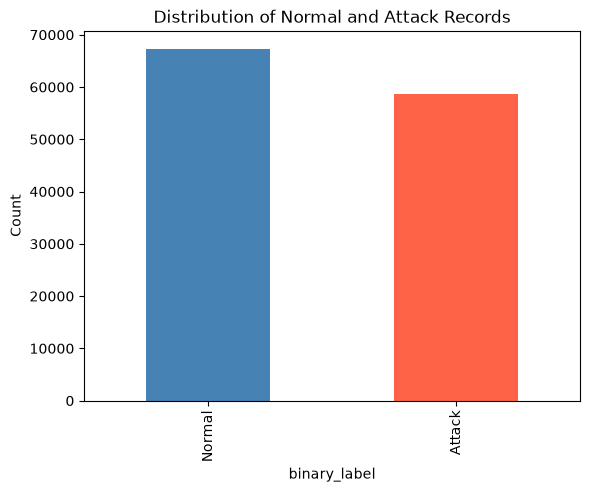

In [11]:
import matplotlib.pyplot as plt

train["binary_label"].value_counts().plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.xticks([0,1],["Normal","Attack"])
plt.title("Distribution of Normal and Attack Records")
plt.ylabel("Count")
plt.show()

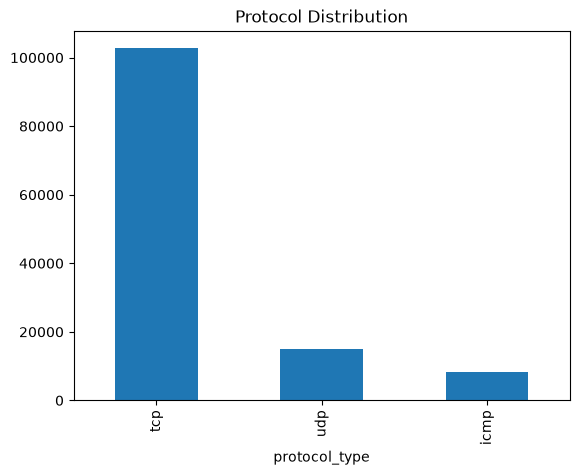

In [19]:
train["protocol_type"].value_counts().plot(kind="bar")
plt.title("Protocol Distribution")
plt.show()

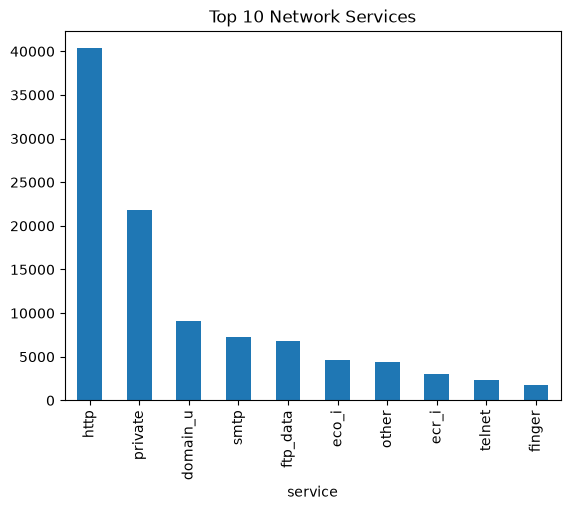

In [20]:
train["service"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Network Services")
plt.show()

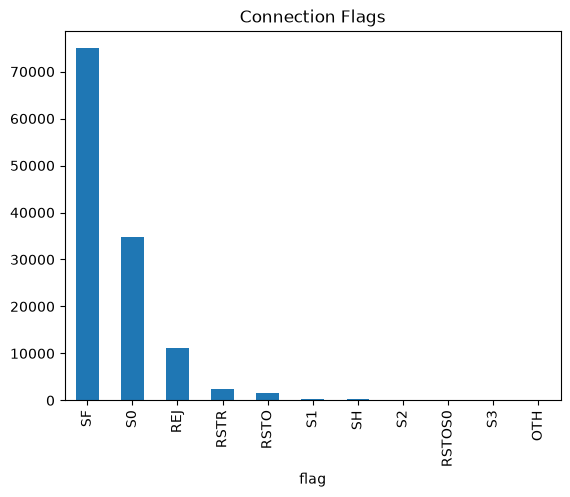

In [21]:
train["flag"].value_counts().plot(kind="bar")
plt.title("Connection Flags")
plt.show()

# This is the end of notebook 1 

Observations :

* Dataset contains 125,973 training records.
* No missing values.
* Three categorical features.
* Class imbalance exists.
* Dataset contains 23 attack types.
* Binary labels were created for initial experimentation.